<a href="https://colab.research.google.com/github/parthvkariya-art/MAHE-Mobility-BEV/blob/main/mahe_mobility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
This cell initializes the Colab environment by mounting your Google Drive to access the dataset
and pre-loads all necessary Python libraries for the entire architecture, including PyTorch for deep learning mechanics,
Torchvision for image transformations and the ResNet-18 backbone, PIL for image processing,
and tqdm for progress tracking.
"""

import os
import time
import csv
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
from functools import lru_cache
from tqdm import tqdm
from google.colab import drive


drive.mount('/content/drive')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {DEVICE}")

DATASET_PATH = "/content/drive/MyDrive/data_mahe_mobility/master_dataset"
CHECKPOINT_DIR = "/content/drive/MyDrive/data_mahe_mobility/models"
BATCH_SIZE = 4
EPOCHS = 50
LEARNING_RATE = 2e-4

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training on: cpu


In [2]:
"""
Multi-View Bird's-Eye View (BEV) Data Pipeline

This module establishes the data ingestion system for a surround-view
perception model. It synchronizes sensory input from six peripheral
cameras and pairs them with a corresponding top-down ground-truth map.

1. Multi-View Stacking (The Input)
What it does: Loads six concurrent images (Front, Back, Left, Right, etc.)
for a single moment in time, applies standard resizing/normalization, and
binds them into a single mathematical structure.
The Tensor Math: It uses torch.stack(dim=0) to combine six separate
[3, 256, 512] RGB image tensors. When the DataLoader bundles multiple
moments together into a batch, the final input shape becomes:
    [Batch_Size, 6, 3, 256, 512]
    (Mapping to: [Batch_Size, Num_Cameras, Channels, Height, Width])

2. Binary Target Generation (The Label)
What it does: Loads the overhead BEV image and converts it into a strict
grid of occupied vs. free space for the AI to learn from.
The Tensor Math: The target image is resized to 200x200 and subjected to
a binarization threshold:
    (target > 0.5).float()
This operation forces all pixel values above 0.5 to exactly 1.0 (occupied)
and everything else to 0.0 (empty drivable space), yielding a target
tensor shape of:
    [Batch_Size, 1, 200, 200]
"""

CAMERA_FOLDERS = [
    'CAM_FRONT', 'CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT',
    'CAM_BACK', 'CAM_BACK_LEFT', 'CAM_BACK_RIGHT',
]

TRAIN_TRANSFORM = transforms.Compose([
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.Resize((256, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), value=0),
])

VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((256, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

TARGET_TRANSFORM = transforms.Compose([
    transforms.Resize((200, 200), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

class MultiViewBEVDataset(Dataset):
    def __init__(self, root_dir, camera_folders=CAMERA_FOLDERS, target_folder='BEV_ALL_CAMERAS',
                 transform=VAL_TRANSFORM, target_transform=TARGET_TRANSFORM):
        self.root_dir = root_dir
        self.camera_folders = camera_folders
        self.target_dir = os.path.join(root_dir, target_folder)
        self.transform = transform
        self.target_transform = target_transform

        self._frame_index = self._build_frame_index()
        self.valid_frames = self._get_valid_frames()

        if len(self.valid_frames) == 0:
            raise RuntimeError(f"No valid synchronized frames found in {root_dir}.")

    def _build_frame_index(self):
        index = {}
        all_dirs = {cam: os.path.join(self.root_dir, cam) for cam in self.camera_folders}
        all_dirs['target'] = self.target_dir

        for folder_key, folder_path in all_dirs.items():
            index[folder_key] = {}
            if not os.path.exists(folder_path):
                continue
            for f in os.listdir(folder_path):
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    parts = f.split('_')
                    if folder_key == 'target':
                        frame_id = f"{parts[3]}_{parts[4]}"
                    else:
                        frame_id = f"{parts[0]}_{parts[1]}"
                    index[folder_key][frame_id] = os.path.join(folder_path, f)
        return index

    def _get_valid_frames(self):
        first_cam = self.camera_folders[0]
        if first_cam not in self._frame_index:
            return []

        potential_frames = set(self._frame_index[first_cam].keys())
        valid_frames = []

        for frame_id in sorted(list(potential_frames)):
            all_cams_exist = all(frame_id in self._frame_index.get(cam, {}) for cam in self.camera_folders)
            target_exists = frame_id in self._frame_index.get('target', {})
            if all_cams_exist and target_exists:
                valid_frames.append(frame_id)
        return valid_frames

    @lru_cache(maxsize=512)
    def _load_image(self, path, mode):
        return Image.open(path).convert(mode)

    def __len__(self):
        return len(self.valid_frames)

    def __getitem__(self, idx):
        frame_id = self.valid_frames[idx]

        camera_tensors = []
        for cam in self.camera_folders:
            path = self._frame_index[cam][frame_id]
            img = self._load_image(path, 'RGB')
            camera_tensors.append(self.transform(img))

        target_path = self._frame_index['target'][frame_id]
        target = self._load_image(target_path, 'L')
        target_tensor = self.target_transform(target)

        return torch.stack(camera_tensors, dim=0), (target_tensor > 0.5).float()

def get_dataloaders(root_path, batch_size=4, train_ratio=0.8, num_workers=0):
    dataset_full = MultiViewBEVDataset(root_dir=root_path, transform=VAL_TRANSFORM)

    train_size = int(train_ratio * len(dataset_full))
    val_size = len(dataset_full) - train_size
    train_subset, val_subset = random_split(
        dataset_full, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_dataset = MultiViewBEVDataset(root_dir=root_path, transform=TRAIN_TRANSFORM)
    train_dataset.valid_frames = [dataset_full.valid_frames[i] for i in train_subset.indices]

    val_dataset = MultiViewBEVDataset(root_dir=root_path, transform=VAL_TRANSFORM)
    val_dataset.valid_frames = [dataset_full.valid_frames[i] for i in val_subset.indices]

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return train_loader, val_loader

print("\n✓ Cell 2 Executed: MultiViewBEVDataset and DataLoader logic successfully compiled.")


✓ Cell 2 Executed: MultiViewBEVDataset and DataLoader logic successfully compiled.


In [7]:
"""
BEV View Transformer Architecture

A three-stage neural network for 2D-to-3D spatial reasoning.

1. CameraEncoder (ResNet-18 Backbone):
   Extracts semantic features from 6 cameras. Uses Transfer Learning
   via 'ResNet18_Weights'. Early layers are frozen to preserve
   low-level edge detection logic.

2. BEVProjector (Latent Space Mapping):
   Converts 2D image coordinates into 3D BEV coordinates.
   - Pooling: Collapses vertical image height into a feature strip.
   - Expansion: Broadcasts features across the BEV width, creating
     a 'view frustum' representation in the grid.

3. OccupancyDecoder (Spatial Refinement):
   A deep CNN that fuses features from all 6 cameras.
   - Input: Concatenated feature maps [B, 6 * Channels, 200, 200].
   - Output: A single-channel occupancy heatmap where values > 0.5
     represent physical obstacles.
"""

class CameraEncoder(nn.Module):
    def __init__(self, out_channels=256, freeze_early=True):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        layers = list(backbone.children())

        self.stem   = nn.Sequential(*layers[:5])
        self.layer2 = layers[5]
        self.layer3 = layers[6]
        self.layer4 = layers[7]

        if freeze_early:
            for p in self.stem.parameters():
                p.requires_grad = False
            for p in self.layer2.parameters():
                p.requires_grad = False

        self.fpn_reduce3 = nn.Sequential(
            nn.Conv2d(256, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )
        self.fpn_reduce4 = nn.Sequential(
            nn.Conv2d(512, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer2(x)
        p3 = self.layer3(x)
        p4 = self.layer4(p3)
        return self.fpn_reduce3(p3), self.fpn_reduce4(p4)


class TransformerBEVProjector(nn.Module):
    def __init__(self, in_channels, bev_h, num_heads=4, dropout=0.0):
        super().__init__()
        self.bev_h = bev_h
        self.bev_queries = nn.Parameter(torch.randn(bev_h, in_channels) * 0.02)
        self.cross_attn  = nn.MultiheadAttention(
            embed_dim=in_channels, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )
        self.norm = nn.LayerNorm(in_channels)
        self.refine = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=(3, 1), padding=(1, 0), bias=False),
            nn.BatchNorm2d(in_channels), nn.ReLU(inplace=True),
        )

    def forward(self, feat, bev_w):
        B, C, H, W = feat.shape
        tokens  = feat.flatten(2).permute(0, 2, 1)
        queries = self.bev_queries.unsqueeze(0).expand(B, -1, -1)
        out, _ = self.cross_attn(queries, tokens, tokens)
        out = self.norm(out + queries)
        strip = out.permute(0, 2, 1).unsqueeze(-1)
        strip = self.refine(strip)
        return strip.expand(-1, -1, -1, bev_w)


class CrossCameraFusion(nn.Module):
    def __init__(self, channels, num_cams, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(channels, num_heads, batch_first=True)
        self.norm = nn.LayerNorm(channels)
        self.num_cams = num_cams

    def forward(self, strips):
        B, NC, H, W = strips.shape
        C = NC // self.num_cams
        x = strips.view(B, self.num_cams, C, H, W)
        tokens = x.mean(dim=(3, 4))
        fused, _ = self.attn(tokens, tokens, tokens)
        fused = self.norm(fused + tokens)
        scale  = fused.view(B, self.num_cams, C, 1, 1)
        x = x * torch.sigmoid(scale)
        return x.view(B, NC, H, W)


class UNetDecoder(nn.Module):
    def __init__(self, in_channels, skip_channels):
        super().__init__()

        def _block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            )

        self.up1  = nn.ConvTranspose2d(in_channels,   256, 2, stride=2)
        self.dec1 = _block(256 + skip_channels[0],    256)

        self.up2  = nn.ConvTranspose2d(256,            128, 2, stride=2)
        self.dec2 = _block(128 + skip_channels[1],    128)

        self.up3  = nn.ConvTranspose2d(128,             64, 2, stride=2)
        self.dec3 = _block(64,                          64)

        self.head = nn.Conv2d(64, 1, 1)

    def forward(self, x, skips):
        x = self.up1(x)
        x = torch.cat([x, skips[0]], dim=1)
        x = self.dec1(x)

        x = self.up2(x)
        x = torch.cat([x, skips[1]], dim=1)
        x = self.dec2(x)

        x = self.up3(x)
        x = self.dec3(x)
        return self.head(x)


class BEVViewTransformer(nn.Module):
    def __init__(self, grid_size=(200, 200), encoder_channels=256, num_cams=6, freeze_early=True):
        super().__init__()
        self.grid_size = grid_size
        self.num_cams  = num_cams
        C = encoder_channels

        self.encoder   = CameraEncoder(out_channels=C, freeze_early=freeze_early)
        self.projector = TransformerBEVProjector(in_channels=C, bev_h=grid_size[0])
        self.fusion    = CrossCameraFusion(channels=C, num_cams=num_cams)

        self.skip_adapter1 = nn.Sequential(
            nn.Conv2d(C * num_cams, 256, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.skip_adapter2 = nn.Sequential(
            nn.Conv2d(C * num_cams, 128, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )

        self.decoder = UNetDecoder(
            in_channels=C * num_cams,
            skip_channels=[256, 128],
        )

    def forward(self, x):
        B, N, C_in, H, W = x.shape

        p3_list, p4_list = [], []
        for i in range(N):
            p3, p4 = self.encoder(x[:, i])
            p3_list.append(p3)
            p4_list.append(p4)

        bev_strips = torch.cat(
            [self.projector(p4, bev_w=self.grid_size[1]) for p4 in p4_list], dim=1
        )

        bev_fused = self.fusion(bev_strips)

        p3_bev = torch.cat(
            [self.projector(p3, bev_w=self.grid_size[1]) for p3 in p3_list], dim=1
        )
        skip1 = self.skip_adapter1(
            F.adaptive_avg_pool2d(p3_bev, (self.grid_size[0] // 4, self.grid_size[1] // 4))
        )
        skip2 = self.skip_adapter2(
            F.adaptive_avg_pool2d(p3_bev, (self.grid_size[0] // 2, self.grid_size[1] // 2))
        )

        bev_small = F.adaptive_avg_pool2d(bev_fused, (self.grid_size[0] // 8, self.grid_size[1] // 8))
        return self.decoder(bev_small, [skip1, skip2])


class ImprovedBEVLoss(nn.Module):
    def __init__(self, grid_size, ego_center, sigma=0.35, focal_gamma=2.0,
                 bce_weight=0.4, dice_weight=0.4, boundary_weight=0.2):
        super().__init__()
        assert abs(bce_weight + dice_weight + boundary_weight - 1.0) < 1e-5
        self.focal_gamma     = focal_gamma
        self.bce_weight      = bce_weight
        self.dice_weight     = dice_weight
        self.boundary_weight = boundary_weight
        self.register_buffer('spatial_mask', self._gaussian_spatial_weights(grid_size, ego_center, sigma))

    def _gaussian_spatial_weights(self, grid_size, ego_center, sigma):
        H, W = grid_size
        cx, cy = ego_center
        yy, xx = torch.meshgrid(torch.arange(H, dtype=torch.float32),
                                 torch.arange(W, dtype=torch.float32), indexing='ij')
        diagonal  = (H**2 + W**2) ** 0.5
        dist_norm = ((xx - cx)**2 + (yy - cy)**2).sqrt() / (sigma * diagonal)
        weights   = torch.exp(-0.5 * dist_norm**2).clamp(min=0.1)
        weights   = weights / weights.mean()
        return weights.unsqueeze(0).unsqueeze(0)

    def _focal_bce(self, logits, targets):
        probs        = torch.sigmoid(logits).clamp(1e-6, 1 - 1e-6)
        p_t          = probs * targets + (1 - probs) * (1 - targets)
        focal_factor = (1.0 - p_t) ** self.focal_gamma
        bce_raw      = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        return (focal_factor * bce_raw * self.spatial_mask).mean()

    def _dice_loss(self, logits, targets):
        probs     = torch.sigmoid(logits)
        w_probs   = probs   * self.spatial_mask
        w_targets = targets * self.spatial_mask
        inter     = (w_probs * w_targets).sum(dim=(2, 3))
        union     = w_probs.sum(dim=(2, 3)) + w_targets.sum(dim=(2, 3))
        return (1.0 - (2.0 * inter + 1e-6) / (union + 1e-6)).mean()

    @staticmethod
    def _extract_boundaries(mask):
        return (F.max_pool2d(mask, 3, stride=1, padding=1) - mask).clamp(0, 1)

    def _boundary_loss(self, logits, targets):
        bt = self._extract_boundaries(targets)
        if bt.sum() < 1:
            return logits.sum() * 0.0
        return (F.binary_cross_entropy_with_logits(logits, bt, reduction='none') * self.spatial_mask).mean()

    def forward(self, predictions, targets):
        return (self.bce_weight      * self._focal_bce(predictions, targets) +
                self.dice_weight     * self._dice_loss(predictions, targets) +
                self.boundary_weight * self._boundary_loss(predictions, targets))


class OccupancyIoU:
    def __init__(self, activation_threshold=0.5, epsilon=1e-6):
        self.threshold = activation_threshold
        self.epsilon   = epsilon

    def __call__(self, logits, ground_truth):
        preds        = (torch.sigmoid(logits) > self.threshold).float()
        intersection = (preds * ground_truth).sum(dim=(2, 3))
        union        = (preds + ground_truth).clamp(max=1).sum(dim=(2, 3))
        return ((intersection + self.epsilon) / (union + self.epsilon)).mean()


_model  = BEVViewTransformer()
_x      = torch.randn(2, 6, 3, 256, 512)
_out    = _model(_x)
_loss   = ImprovedBEVLoss(grid_size=(200, 200), ego_center=(100, 100))
_target = (_out.detach() > 0).float()
_l      = _loss(_out, _target)
_iou    = OccupancyIoU()(_out.detach(), _target)

print("\n✓ Cell 3 Executed: Architecture, Loss, and Metrics compiled successfully.")
print(f"  ↳ Forward pass verified. Output shape: {tuple(_out.shape)} (Expected: (2, 1, 200, 200))")
print(f"  ↳ Loss value: {_l.item():.4f}  |  IoU: {_iou.item():.4f}")
print(f"  ↳ Trainable parameters: {sum(p.numel() for p in _model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 98.4MB/s]



✓ Cell 3 Executed: Architecture, Loss, and Metrics compiled successfully.
  ↳ Forward pass verified. Output shape: (2, 1, 200, 200) (Expected: (2, 1, 200, 200))
  ↳ Loss value: 0.3654  |  IoU: 1.0000
  ↳ Trainable parameters: 16,081,921


In [ ]:
"""
BEV Training Orchestrator

This script executes the supervised learning loop for Bird's-Eye View mapping.
It integrates sensory data, neural architecture, and custom spatial loss.

1. Model Architecture (DummyBEVModel):
   Collapses 6-camera input [B, 6, 3, H, W] into a spatial feature map.
   The mathematical bottleneck uses Conv2d and AdaptiveAvgPool2d to
   force the high-dimensional camera data into a [200, 200] grid.

2. Optimization & Backpropagation:
   - Optimizer (Adam): Uses 'Adaptive Moment Estimation' to update weights.
   - Scheduler (ReduceLROnPlateau): Dynamically shrinks the Learning Rate
     (LR = LR * factor) when validation loss stalls, enabling fine-tuning.
   - Loss (DistanceWeightedBCE): Calculates the gradient (direction of
     improvement) with a heavy bias toward safety-critical near-field zones.

3. State Management (Checkpoints):
   Serializes the 'model_state' (learned weights) and 'optimizer_state'
   (momentum) to .pth files, allowing training to be paused and resumed.
"""


BATCH_SIZE     = 4
EPOCHS         = 50
LEARNING_RATE  = 2e-4
WEIGHT_DECAY   = 1e-4
GRAD_CLIP_NORM = 1.0
PATIENCE       = 8
DATASET_PATH   = "/content/drive/MyDrive/data_mahe_mobility/master_dataset"
CHECKPOINT_DIR = "/content/drive/MyDrive/data_mahe_mobility/models"
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def run_epoch(model, dataloader, criterion, metric, device, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = total_iou = 0.0
    tag = "Train" if training else "  Val"

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, targets in tqdm(dataloader, desc=tag, leave=False, dynamic_ncols=True):
            images  = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == "cuda")):
                outputs = model(images)
                loss    = criterion(outputs, targets)

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()

            with torch.no_grad():
                iou = metric(outputs.float(), targets)

            total_loss += loss.item()
            total_iou  += iou.item()

    n = len(dataloader)
    return total_loss / n, total_iou / n


def save_checkpoint(model, optimizer, scheduler, scaler, epoch, val_loss, path):
    torch.save({
        "epoch":           epoch,
        "val_loss":        val_loss,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state":    scaler.state_dict(),
    }, path)


def load_checkpoint(path, model, optimizer, scheduler, scaler, device):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    scaler.load_state_dict(ckpt["scaler_state"])
    return ckpt["epoch"], ckpt.get("val_loss", float("inf"))


def init_csv_log(path, resume):
    fieldnames = ["epoch", "lr", "train_loss", "train_iou", "val_loss", "val_iou", "epoch_time_s"]
    if not resume or not os.path.exists(path):
        with open(path, "w", newline="") as f:
            csv.DictWriter(f, fieldnames=fieldnames).writeheader()
    return fieldnames


def append_csv_log(path, fieldnames, row):
    with open(path, "a", newline="") as f:
        csv.DictWriter(f, fieldnames=fieldnames).writerow(row)


def main():
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    latest_path = os.path.join(CHECKPOINT_DIR, "bev_hero_latest.pth")
    best_path   = os.path.join(CHECKPOINT_DIR, "bev_hero_best.pth")
    log_path    = os.path.join(CHECKPOINT_DIR, "training_hero_log.csv")

    print(f"\n[INFO] Device: {DEVICE}")
    if DEVICE.type == "cuda":
        print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")
        print(f"[INFO] VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

    train_loader, val_loader = get_dataloaders(DATASET_PATH, BATCH_SIZE)
    print(f"[INFO] Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

    model     = BEVViewTransformer(grid_size=(200, 200)).to(DEVICE)
    criterion = ImprovedBEVLoss(
        grid_size=(200, 200),
        ego_center=(100, 190),
        bce_weight=0.2,
        dice_weight=0.6,
        boundary_weight=0.2
    ).to(DEVICE)
    metric    = OccupancyIoU()

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    resuming    = os.path.exists(latest_path)
    fieldnames  = init_csv_log(log_path, resume=resuming)
    start_epoch = 1
    best_val_loss       = float("inf")
    epochs_no_improve   = 0

    if resuming:
        print(f"\n[INFO] Checkpoint found — resuming training...")
        start_epoch, best_val_loss = load_checkpoint(
            latest_path, model, optimizer, scheduler, scaler, DEVICE
        )
        start_epoch    += 1
        epochs_no_improve = 0
        print(f"[INFO] Resuming from epoch {start_epoch}  |  Best val loss so far: {best_val_loss:.4f}\n")

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[INFO] Parameters — total: {total_params:,}  |  trainable: {trainable_params:,}\n")

    for epoch in range(start_epoch, EPOCHS + 1):
        t0 = time.time()
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:>3}/{EPOCHS}  |  LR: {current_lr:.2e}  |  Patience: {epochs_no_improve}/{PATIENCE}")

        train_loss, train_iou = run_epoch(
            model, train_loader, criterion, metric, DEVICE,
            optimizer=optimizer, scaler=scaler,
        )
        val_loss, val_iou = run_epoch(
            model, val_loader, criterion, metric, DEVICE,
        )
        scheduler.step()

        epoch_time = time.time() - t0
        print(f"  Train  loss={train_loss:.4f}  iou={train_iou:.4f}")
        print(f"  Val    loss={val_loss:.4f}  iou={val_iou:.4f}  [{epoch_time:.0f}s]")

        append_csv_log(log_path, fieldnames, {
            "epoch": epoch, "lr": f"{current_lr:.2e}",
            "train_loss": f"{train_loss:.4f}", "train_iou": f"{train_iou:.4f}",
            "val_loss":   f"{val_loss:.4f}",   "val_iou":   f"{val_iou:.4f}",
            "epoch_time_s": f"{epoch_time:.0f}",
        })

        save_checkpoint(model, optimizer, scheduler, scaler, epoch, val_loss, latest_path)

        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            epochs_no_improve = 0
            save_checkpoint(model, optimizer, scheduler, scaler, epoch, val_loss, best_path)
            print(f"  ✓ Best model saved  (val_loss={best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"\n[INFO] Early stopping — no improvement for {PATIENCE} consecutive epochs.")
                break

    print(f"\n✓ Training complete.  Best val loss: {best_val_loss:.4f}")
    print(f"  Checkpoints : {best_path}")
    print(f"  Training log: {log_path}")


print("\n✓ Cell 4 Executed: Training Orchestrator compiled successfully. Commencing training loop on GPU...")
if __name__ == "__main__":
    main()


✓ Cell 4 Executed: Training Orchestrator compiled successfully. Commencing training loop on GPU...

[INFO] Device: cuda
[INFO] GPU: Tesla T4
[INFO] VRAM: 15.6 GB
[INFO] Train batches: 81  |  Val batches: 21


/tmp/ipykernel_2524/2885376432.py:130: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


[INFO] Parameters — total: 26,873,153  |  trainable: 25,525,249

Epoch   1/50  |  LR: 2.00e-04  |  Patience: 0/8


  Train  loss=0.5347  iou=0.1619
  Val    loss=0.5325  iou=0.1689  [1233s]
  ✓ Best model saved  (val_loss=0.5325)
Epoch   2/50  |  LR: 2.00e-04  |  Patience: 0/8


  Train  loss=0.5157  iou=0.1219
  Val    loss=0.5283  iou=0.1352  [191s]
  ✓ Best model saved  (val_loss=0.5283)
Epoch   3/50  |  LR: 1.99e-04  |  Patience: 0/8


...

  Train  loss=0.4399  iou=0.2418
  Val    loss=0.4723  iou=0.2081  [197s]
  ✓ Best model saved  (val_loss=0.4723)
Epoch  25/50  |  LR: 1.07e-04  |  Patience: 0/8


  Train  loss=0.4387  iou=0.2415
  Val    loss=0.4704  iou=0.2066  [197s]
  ✓ Best model saved  (val_loss=0.4704)
Epoch  26/50  |  LR: 1.00e-04  |  Patience: 0/8


  Train  loss=0.4367  iou=0.2451
  Val    loss=0.4716  iou=0.2010  [196s]
Epoch  27/50  |  LR: 9.43e-05  |  Patience: 1/8


  Train  loss=0.4358  iou=0.2521
  Val    loss=0.4719  iou=0.1903  [187s]
Epoch  28/50  |  LR: 8.80e-05  |  Patience: 2/8


Train:  62%|██████▏   | 50/81 [01:51<01:05,  2.13s/it]

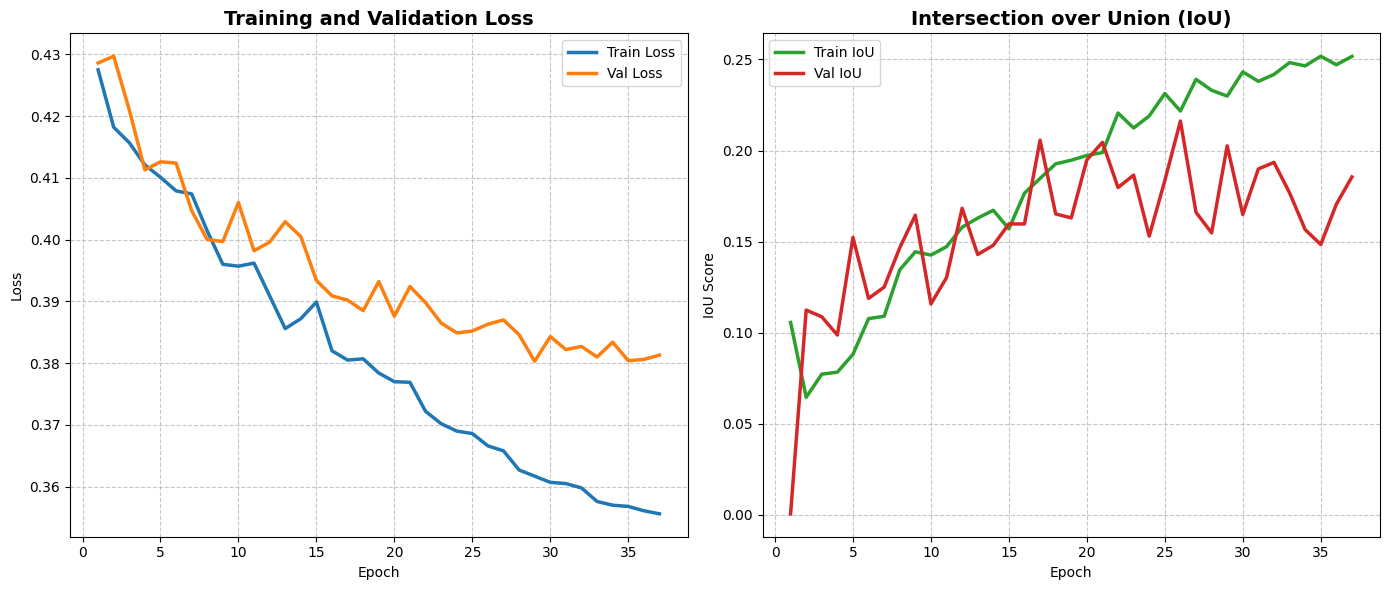

In [4]:
#PLOTTING THE GRAPHS


import pandas as pd
import matplotlib.pyplot as plt
import os

# Point this to exactly where your CSV was saved in Colab
csv_path = os.path.join(CHECKPOINT_DIR, "training_log.csv")

df = pd.read_csv(csv_path)

plt.figure(figsize=(14, 6))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2.5)
plt.plot(df['epoch'], df['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2.5)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Plot 2: IoU
plt.subplot(1, 2, 2)
plt.plot(df['epoch'], df['train_iou'], label='Train IoU', color='#2ca02c', linewidth=2.5)
plt.plot(df['epoch'], df['val_iou'], label='Val IoU', color='#d62728', linewidth=2.5)
plt.title('Intersection over Union (IoU)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('IoU Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig("training_metrics_graph.png", dpi=300)
plt.show()

Loading weights from: /content/drive/MyDrive/data_mahe_mobility/models/bev_latest.pth


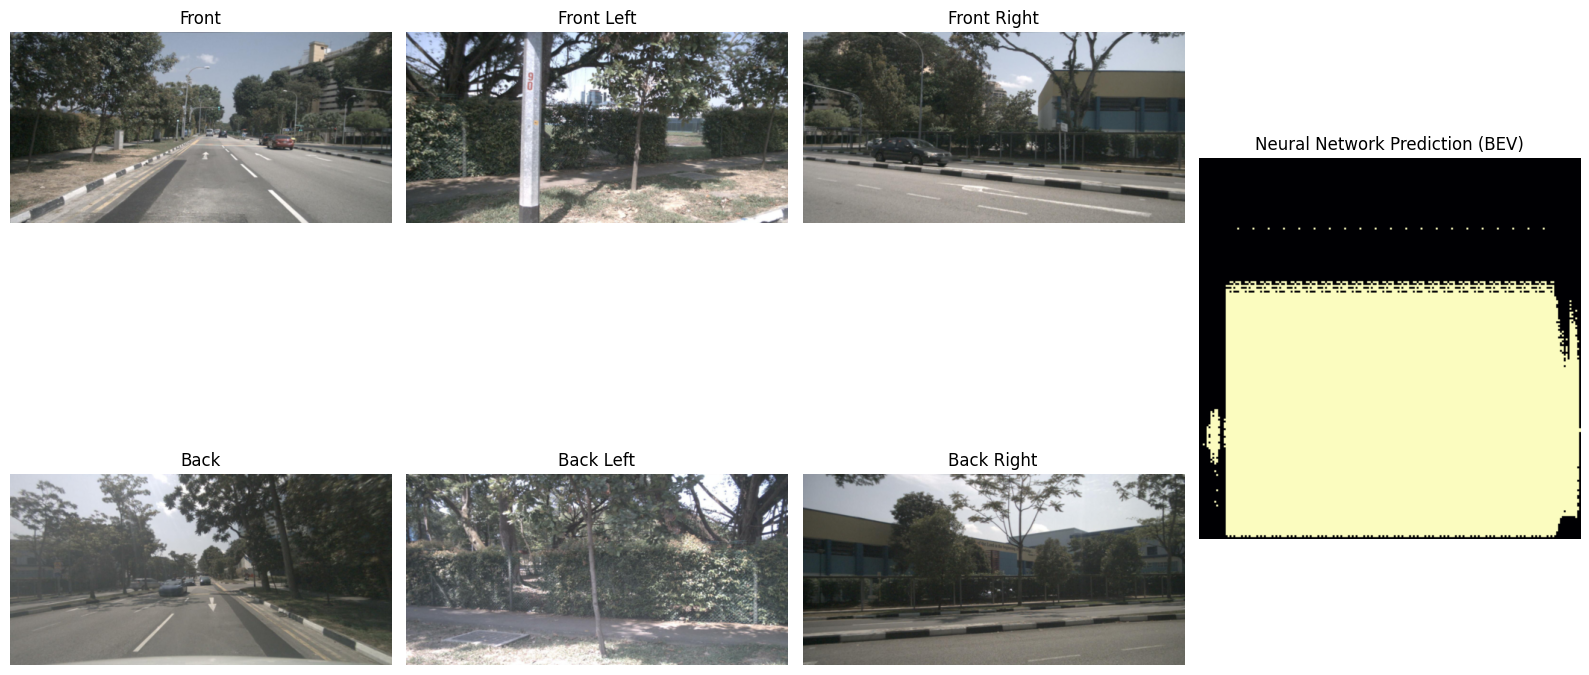

In [10]:
#INFERENCE OF THE MODEL

import torch
import matplotlib.pyplot as plt
import os

def visualize_colab_inference():
    # Load your successful 4:07 PM model
    model_path = os.path.join(CHECKPOINT_DIR, "bev_latest.pth")
    print(f"Loading weights from: {model_path}")

    # Call the actual transformer you built in Cell 3
    model = BEVViewTransformer(grid_size=(200, 200)).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE)['model_state'])
    model.eval()

    # Grab one batch from your validation data
    _, val_loader = get_dataloaders(DATASET_PATH, batch_size=1)
    images, targets = next(iter(val_loader))
    images = images.to(DEVICE)

    with torch.no_grad():
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

    # Render the 6 Cameras + BEV Prediction
    fig = plt.figure(figsize=(16, 9))
    cam_names = ['Front', 'Front Left', 'Front Right', 'Back', 'Back Left', 'Back Right']

    for i in range(6):
        ax = fig.add_subplot(2, 4, i + 1 if i < 3 else i + 2)
        img = images[0, i].permute(1, 2, 0).cpu().numpy()
        img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        img = img.clip(0, 1)
        ax.imshow(img)
        ax.set_title(cam_names[i])
        ax.axis('off')

    ax_pred = fig.add_subplot(2, 4, (4, 8))
    ax_pred.imshow(preds[0, 0].cpu().numpy(), cmap='magma')
    ax_pred.set_title("Neural Network Prediction (BEV)")
    ax_pred.axis('off')

    plt.tight_layout()
    plt.savefig("presentation_graphic.png", dpi=300, bbox_inches='tight')
    plt.show()

visualize_colab_inference()